## Chapter 2 — Tokenization for Science (v2026)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanReznikov/LangChain4LifeSciencesHealthcare)

### Learning objectives
- Explain how subword tokenization (BPE / WordPiece / SentencePiece) splits scientific text.
- Measure **token budgets** for papers, tables, protein/DNA sequences, and SMILES.
- Compare general-purpose vs. domain tokenizers on life-science strings.
- Estimate context-window and cost impact of tokenizer choice.

**Runtime / cost:** CPU-only, no API key required (uses open Hugging Face tokenizers). ~2–4 min.

**Data:** synthetic example strings only.


> **LangChain 1.x note:** This notebook uses the current package layout (`langchain_core`, `langchain_openai`, `langchain_community`) and modern Hugging Face `transformers` tokenizers. It is API-optional: the tokenizer analyses run locally with open models; no paid API calls are required.

## Why tokenization matters more for science than for prose

LLMs see **tokens**, not characters or words. Scientific text is unusually hostile to general-purpose tokenizers:
- **SMILES** (`CC(=O)Oc1ccccc1C(=O)O`) and **SELFIES** have no whitespace and many rare symbols.
- **Sequences** (`MKVLWAALLVTFLAGCQAKVEQ...`) are long runs with no word boundaries.
- **Numbers, units, and chemical formulae** (`1.7e-9`, `µg/mL`, `C8H9NO2`) split unpredictably.

A tokenizer that splits a SMILES into 3× more tokens inflates cost and can hurt model performance. This notebook makes that visible and measurable.

### API / credentials

This notebook is **local-only** — it loads open tokenizers from Hugging Face and does not call any paid LLM API. A Hugging Face token is only needed for gated models; the examples here use public tokenizers.

In [1]:
import os

try:
    from google.colab import userdata  # type: ignore

    IN_COLAB = True
except Exception:
    userdata = None
    IN_COLAB = False

if not IN_COLAB:
    try:
        from dotenv import load_dotenv

        load_dotenv()
    except Exception:
        pass


def get_secret(name, default=None):
    if IN_COLAB and userdata is not None:
        try:
            val = userdata.get(name)
            if val:
                return val
        except Exception:
            pass
    return os.getenv(name, default)


# Only needed if you swap in a gated tokenizer/model. Public tokenizers work without it.
os.environ["HF_TOKEN"] = get_secret("HF_TOKEN", "") or ""
print(
    f"✅ HF token set: {bool(os.environ['HF_TOKEN'])} (source: {'Colab Secrets' if IN_COLAB else 'local env/.env'})"
)

✅ HF token set: True (source: Colab Secrets)


In [2]:
import os

SEED = 42
# Tokenizers to compare. All are public; swap freely.
TOKENIZERS = {
    "gpt2 (BPE)": "gpt2",
    "bert-base (WordPiece)": "bert-base-uncased",
    "llama-3 (BPE)": "NousResearch/Meta-Llama-3-8B",
    "scibert (WordPiece)": "allenai/scibert_scivocab_uncased",
}
RUN_METADATA = {"chapter": 2, "notebook": "tokenization_for_science", "seed": SEED}
print(RUN_METADATA)

{'chapter': 2, 'notebook': 'tokenization_for_science', 'seed': 42}


## Package Installation and Setup

Pinned versions with upper bounds — Last validated: 2026-07-21 (see UPDATE_2026.md).

In [3]:
#@title Installing Python dependencies
%pip install -q "transformers>=4.51,<6" "tokenizers>=0.20,<1" pandas matplotlib

## 1. Load tokenizers

We load each tokenizer and wrap it in a helper that returns token count and the token strings. If a tokenizer fails to download (e.g., gated), we skip it gracefully.

In [4]:
from transformers import AutoTokenizer

loaded = {}
for label, name in TOKENIZERS.items():
    try:
        loaded[label] = AutoTokenizer.from_pretrained(name)
        print(f"✅ {label}: vocab={loaded[label].vocab_size:,}")
    except Exception as e:
        print(f"⚠️  skipped {label} ({name}): {type(e).__name__}: {str(e)[:80]}")


def tok_info(tok, text):
    ids = tok(text, add_special_tokens=False)["input_ids"]
    toks = tok.convert_ids_to_tokens(ids)
    return len(ids), toks


print(f"\nLoaded {len(loaded)} tokenizers")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

✅ llama-3 (BPE): vocab=128,000


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/228k [00:00<?, ?B/s]

✅ scibert (WordPiece): vocab=31,090

Loaded 4 tokenizers


## 2. Scientific example strings

A representative slice of life-science text: a paper sentence, a numeric result, a table row, a SMILES, a SELFIES, and a protein sequence.

In [5]:
EXAMPLES = {
    "paper_sentence": "Aspirin inhibits cyclooxygenase-1 (COX-1) with an IC50 of 1.7 µmol/L in platelets.",
    "numeric_result": "The Ki was 3.4e-9 M (95% CI: 1.2e-9–8.1e-9), measured by surface plasmon resonance.",
    "table_row": "| Imatinib | ABL1 | 0.025 | µM | leukemia | Phase IV |",
    "smiles": "CC(=O)Oc1ccccc1C(=O)O",  # aspirin
    "selfies": "[C][C][=Branch1][C][=O][O][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=Branch1][C][=O][O]",
    "protein_seq": "MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWELALGRFWDYLRWVQTLSEQVQEELLSSQVTQELRALMDETMKELKAYKSELEEQLTPVAEETRARLSKELQAAQARLGADMEDVCGRLVQYRGEVQAMLGQSTEELRVRLASHLRKLRKRLLRDADDLQKRLAVYQAGAREGAERGLSAIRERLGPLVEQGRVRAATVGSLAGQPLQERAQAWGERLRARMEEMGSRTRDRLDEVKEQVAEVRAKLEEQAQQIRLQAEAFQARLKSWFEPLVEDMQRQWAGLVEKVQAAVGTSAAPVPSDNH",
}
for k, v in EXAMPLES.items():
    print(f"{k:16s} chars={len(v):4d}  {v[:60]}{'...' if len(v) > 60 else ''}")

paper_sentence   chars=  82  Aspirin inhibits cyclooxygenase-1 (COX-1) with an IC50 of 1....
numeric_result   chars=  83  The Ki was 3.4e-9 M (95% CI: 1.2e-9–8.1e-9), measured by sur...
table_row        chars=  54  | Imatinib | ABL1 | 0.025 | µM | leukemia | Phase IV |
smiles           chars=  21  CC(=O)Oc1ccccc1C(=O)O
selfies          chars=  87  [C][C][=Branch1][C][=O][O][C][=C][C][=C][C][=C][Ring1][=Bran...
protein_seq      chars= 317  MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQSGQRWELALGRFWDYLRWVQT...


## 3. Token-count comparison

Count tokens per example per tokenizer, and compute a **fertility** (tokens/character) ratio. Higher fertility = more tokens = higher cost and more splitting.

In [6]:
import pandas as pd

rows = []
for ex_name, text in EXAMPLES.items():
    row = {"example": ex_name, "chars": len(text)}
    for label, tok in loaded.items():
        n, _ = tok_info(tok, text)
        row[label] = n
    rows.append(row)

df = pd.DataFrame(rows).set_index("example")
df

,chars,gpt2 (BPE),bert-base (WordPiece),llama-3 (BPE),scibert (WordPiece)
example,,,,,
paper_sentence,82,33,34,33,25
numeric_result,83,37,38,39,36
table_row,54,21,22,22,18
smiles,21,18,18,15,16
selfies,87,54,69,50,69
protein_seq,317,189,1,178,1


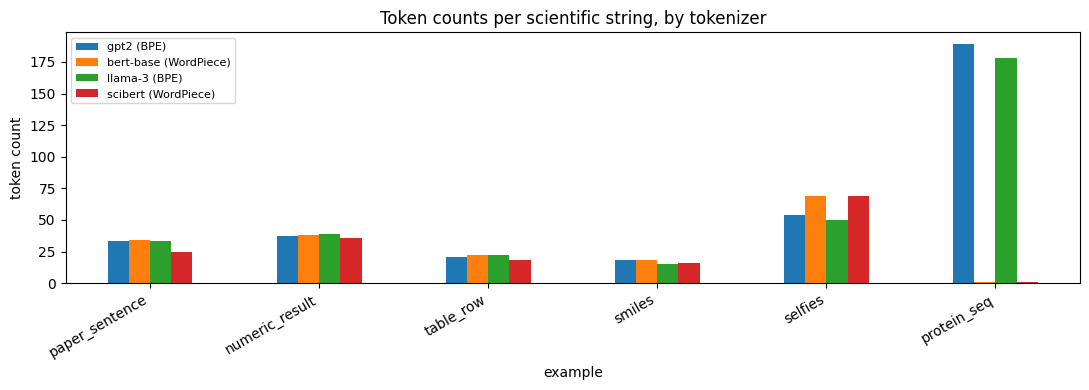

In [7]:
import matplotlib.pyplot as plt

ax = df.drop(columns="chars").plot(kind="bar", figsize=(11, 4))
ax.set_ylabel("token count")
ax.set_title("Token counts per scientific string, by tokenizer")
ax.legend(fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Inspect the actual splits

Token counts hide *how* strings split. Look at the token strings for the SMILES and sequence to see whether meaningful chemical/biological units survive.

In [8]:
for label, tok in loaded.items():
    n, toks = tok_info(tok, EXAMPLES["smiles"])
    print(f"\n=== {label} — SMILES ({n} tokens) ===")
    print(toks)

for label, tok in loaded.items():
    n, toks = tok_info(tok, EXAMPLES["protein_seq"][:60])
    print(f"\n=== {label} — protein[0:60] ({n} tokens) ===")
    print(toks)


=== gpt2 (BPE) — SMILES (18 tokens) ===
['CC', '(', '=', 'O', ')', 'O', 'c', '1', 'cc', 'cc', 'c', '1', 'C', '(', '=', 'O', ')', 'O']

=== bert-base (WordPiece) — SMILES (18 tokens) ===
['cc', '(', '=', 'o', ')', 'o', '##c', '##1', '##cc', '##cc', '##c', '##1', '##c', '(', '=', 'o', ')', 'o']

=== llama-3 (BPE) — SMILES (15 tokens) ===
['CC', '(=', 'O', ')', 'O', 'c', '1', 'cc', 'ccc', '1', 'C', '(=', 'O', ')', 'O']

=== scibert (WordPiece) — SMILES (16 tokens) ===
['cc', '(', '=', 'o', ')', 'oc', '##1', '##ccc', '##cc', '##1', '##c', '(', '=', 'o', ')', 'o']

=== gpt2 (BPE) — protein[0:60] (36 tokens) ===
['MK', 'VL', 'WA', 'ALL', 'VT', 'FLAG', 'C', 'Q', 'AK', 'VE', 'Q', 'AV', 'ET', 'EP', 'EP', 'EL', 'R', 'Q', 'Q', 'T', 'EW', 'Q', 'SG', 'Q', 'RW', 'EL', 'AL', 'GR', 'F', 'WD', 'Y', 'LR', 'W', 'V', 'Q', 'T']

=== bert-base (WordPiece) — protein[0:60] (37 tokens) ===
['mk', '##v', '##l', '##wa', '##all', '##v', '##tf', '##lag', '##c', '##qa', '##k', '##ve', '##qa', '##vet', '##ep', '##e

## 5. Context-window and cost impact

Translate token counts into a rough cost / context budget. Assume a corpus of 1,000 papers averaging 5,000 tokens each (prose), then re-estimate if the chemistry/sequence sections tokenize 2–3× worse under a general tokenizer.

In [9]:
import numpy as np

n_papers, avg_tokens_prose = 1000, 5000
price_per_1k_input = 0.00015  # illustrative; replace with your provider's rate

base_tokens = n_papers * avg_tokens_prose
base_cost = base_tokens / 1000 * price_per_1k_input
print(f"Baseline (prose-only): {base_tokens:,} tokens ≈ ${base_cost:.2f} per pass")

# Inflation factor from the SMILES row (general vs best domain tokenizer)
if "smiles" in df.index and len(loaded) >= 2:
    smi = df.loc["smiles"].drop("chars")
    inflation = smi.max() / max(smi.min(), 1)
    print(f"SMILES token inflation (worst/best tokenizer): {inflation:.2f}×")
    print(
        "→ If 20% of your corpus is SMILES/sequences, a 2–3× tokenizer penalty there "
        "raises total cost by ~20–40%. Choosing a domain tokenizer is a real lever."
    )

Baseline (prose-only): 5,000,000 tokens ≈ $0.75 per pass
SMILES token inflation (worst/best tokenizer): 1.20×
→ If 20% of your corpus is SMILES/sequences, a 2–3× tokenizer penalty there raises total cost by ~20–40%. Choosing a domain tokenizer is a real lever.


## Limitations & safety
- Token-count differences do **not** always predict downstream accuracy; a domain tokenizer helps most when paired with a domain-trained model.
- `vocab_size` shown is the base vocab; some tokenizers add special tokens at encode time.
- Gated tokenizers (e.g., Llama-3 official) require accepting a license + HF token; this notebook used public mirrors to stay runnable.
- Cost numbers are illustrative — check your provider's current pricing.

## Cleanup
Release tokenizer objects.

---
### Further Reading

| Notebook | Relevance |
|----------|-----------|
| **Chapter 2 Embeddings and Tokenizers** | Tokenization impact on embeddings and retrieval |
| **Chapter 2 Models** | Tokenizer comparison tables and model-family overview |


In [10]:
import gc

for k in list(loaded.keys()):
    del loaded[k]
gc.collect()
print("🧹 tokenizers released")

🧹 tokenizers released


## Exercises

1. Which tokenizer split the SMILES into the fewest tokens, and why does that matter for a chemistry LLM?
   <details><summary>Hint</summary>Look at whether ring-closure digits and branches stay intact; a tokenizer that keeps chemically meaningful units reduces spurious fragmentation.</details>
2. Why did the protein sequence tokenize so differently across tokenizers even though it's only 20 distinct letters?
   <details><summary>Hint</summary>BPE merges are learned from natural text; amino-acid trigram frequencies differ from English, so merge tables don't align with biological motifs.</details>
3. Give one scenario where a *higher* token count is acceptable.
   <details><summary>Hint</summary>When a domain model was trained with that tokenizer, the richer splitting may match its training distribution and improve accuracy despite cost.</details>

### Task A — Tokenizer shoot-out
Add a biomedical tokenizer (e.g., `dmis-lab/biobert-base-cased-v1.1` or a chemistry tokenizer) and re-run the comparison. Which strings improve most?

### Task B — SELFIES vs SMILES
Compare token counts for `selfies` vs `smiles` across tokenizers. Hypothesize why SELFIES' bracketed grammar changes fragmentation.

### Task C — Token-budget estimator
Write a function `estimate_cost(texts, tokenizer, price_per_1k)` that returns total tokens and cost for a list of documents. Test it on `EXAMPLES.values()`.

### Task D — Long-document budget
Take one full paper abstract + methods section (paste your own). Measure tokens under two tokenizers and compute how many fit in a 128k context window vs an 8k window.